<a href="https://colab.research.google.com/github/vivekkumarbehera/Machine_learning_Pratical_Implement/blob/main/CartoonifyanImageWithopenCv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install easygui
import cv2
import easygui #this we will use this the Application meaning photos ,videos ets any where in the Storage
import numpy as np
import imageio
import sys
import matplotlib.pyplot as plt
import os
import tkinter as tk
from tkinter import filedialog
from tkinter import *
from PIL import ImageTk, Image

In [30]:
def upload(image_path_for_colab='/content/sample_data/pass.jpeg'):
    # In a Colab environment, easygui.fileopenbox() causes a TclError
    # due to the lack of a display server. For demonstration in Colab,
    # we will use a predefined image path or one provided as an argument.
    # If you were running this on a local machine with a GUI, easygui would work.
    ImagePath = image_path_for_colab

    # You can uncomment the line below and comment the above to use easygui
    # if running in a local environment with a graphical display:
    # ImagePath=easygui.fileopenbox()

    if ImagePath:
        cartoonify(ImagePath)
    else:
        print("No image path provided or file selection cancelled.")

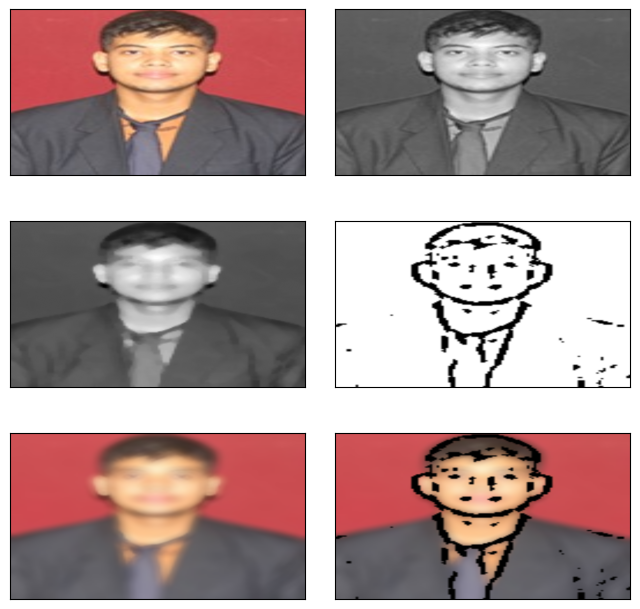

In [31]:
upload()

In [27]:
def cartoonify(ImagePath):
    #read the image
    originalmage = cv2.imread(ImagePath)
    originalmage = cv2.cvtColor(originalmage, cv2.COLOR_BGR2RGB)
    #print(image)  # image is stored in form of numbers

    # confirm that image is chosen
    if originalmage is None:
        print("Can not find any image. Choose appropriate file")
        sys.exit()

    ReSized1 = cv2.resize(originalmage, (960, 540))
    #plt.imshow(ReSized1, cmap='gray')

    #converting an image to grayscale
    grayScaleImage = cv2.cvtColor(originalmage, cv2.COLOR_BGR2GRAY)
    ReSized2 = cv2.resize(grayScaleImage, (960, 540))
    #plt.imshow(ReSized2, cmap='gray')

    #applying median blur to smoothen an image
    smoothGrayScale = cv2.medianBlur(grayScaleImage, 5)
    ReSized3 = cv2.resize(smoothGrayScale, (960, 540))
    #plt.imshow(ReSized3, cmap='gray')

    #retrieving the edges for cartoon effect
    #by using adaptive thresholding
    getEdge = cv2.adaptiveThreshold(smoothGrayScale, 255,
                                    cv2.ADAPTIVE_THRESH_MEAN_C,
                                    cv2.THRESH_BINARY, 9, 9)
    ReSized4 = cv2.resize(getEdge, (960, 540))
    #plt.imshow(ReSized4, cmap='gray')

    #applying bilateral filter to remove noise
    #and keep edge sharp as required
    colorImage = cv2.bilateralFilter(originalmage, 9, 300, 300)
    ReSized5 = cv2.resize(colorImage, (960, 540))
    #plt.imshow(ReSized5, cmap='gray')

    #masking edged image with 'colorImage' output
    cartoonImage = cv2.bitwise_and(colorImage, colorImage, mask=getEdge)
    ReSized6 = cv2.resize(cartoonImage, (960, 540))
    #plt.imshow(ReSized6, cmap='gray')

    # Plotting the whole transition
    images=[ReSized1, ReSized2, ReSized3, ReSized4, ReSized5, ReSized6]
    fig, axes = plt.subplots(3,2, figsize=(8,8), subplot_kw={'xticks':[], 'yticks':[]}, gridspec_kw=dict(hspace=0.1, wspace=0.1))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i], cmap='gray')
    # Display the final cartoonified image after all steps
    plt.show()

    # Return the final cartoonified image and the original path for saving
    return ReSized6, ImagePath

def save(image_to_save, original_image_path):
    #saving an image using imwrite()
    newName="cartoonified_Image"
    path1 = os.path.dirname(original_image_path)
    extension=os.path.splitext(original_image_path)[1]
    path = os.path.join(path1, newName+extension)
    cv2.imwrite(path, cv2.cvtColor(image_to_save, cv2.COLOR_RGB2BGR))
    I = "Image saved by name " + newName +" at "+ path
    tk.messagebox.showinfo(title=None, message=I)